#Atividade Prática: Visualização Estatística de Dados com Seaborn

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# Configuração de estilo global do Seaborn
sns.set_theme(style="whitegrid", palette="muted")

# Geração de dados sintéticos
np.random.seed(101)
n = 300

dados = {
    'idade': np.random.normal(35, 10, n).astype(int),
    'plano': np.random.choice(['Gratuito', 'Básico', 'Pro'], n, p=[0.5, 0.3, 0.2]),
    'tempo_uso_horas': np.random.uniform(1, 50, n),
    'bugs_reportados': np.random.poisson(2, n),
    'satisfacao': np.random.randint(1, 11, n)
}

In [3]:
df_sistema = pd.DataFrame(dados)

# Ajustando regras de negócio sintéticas para gerar correlações visuais
df_sistema.loc[df_sistema['plano'] == 'Pro', 'tempo_uso_horas'] += 15
df_sistema.loc[df_sistema['plano'] == 'Pro', 'satisfacao'] += 2
df_sistema['satisfacao'] = df_sistema['satisfacao'] - (df_sistema['bugs_reportados'] * 0.5)
df_sistema['satisfacao'] = df_sistema['satisfacao'].clip(1, 10).astype(int)
df_sistema['idade'] = df_sistema['idade'].clip(18, 70)

#Parte 01
##Distribuições e Contagens (Básico)

1. Crie um gráfico de barras para exibir a contagem de usuários por tipo de plano. Utilize a função countplot e ordene as barras pela frequência.<br>


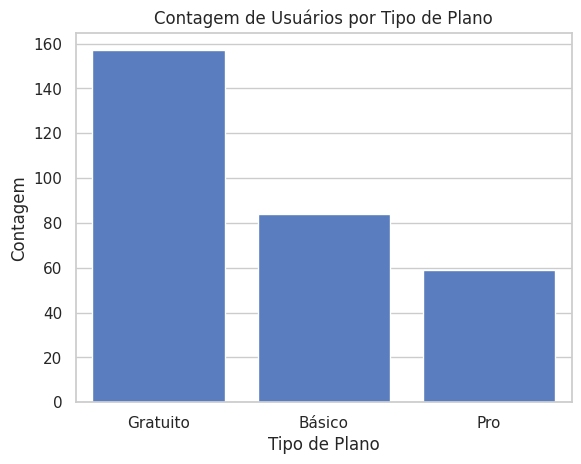

In [5]:
sns.countplot(data=df_sistema, x='plano', order=df_sistema['plano'].value_counts().index)
plt.title('Contagem de Usuários por Tipo de Plano')
plt.xlabel('Tipo de Plano')
plt.ylabel('Contagem')
plt.show()

2. Analise a distribuição da variável idade utilizando um histplot. Adicione a curva de densidade (KDE) para suavizar a visualização.<br>


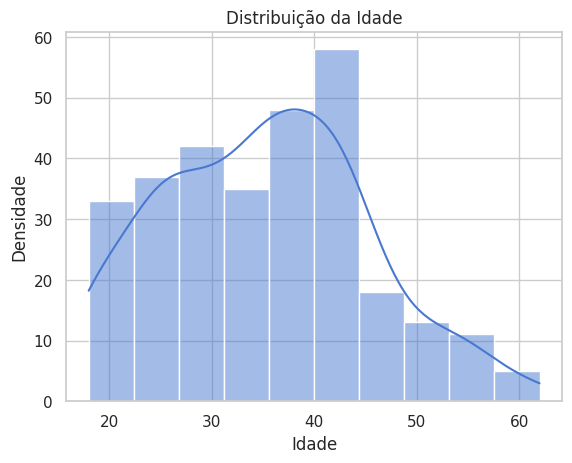

In [6]:
sns.histplot(data=df_sistema, x='idade', kde=True)
plt.title('Distribuição da Idade')
plt.xlabel('Idade')
plt.ylabel('Densidade')
plt.show()

#Parte 02
##Relações Categóricas e Numéricas (Intermediário)

3. Construa um boxplot para comparar a distribuição do tempo_uso_horas entre os diferentes tipos de plano.<br>


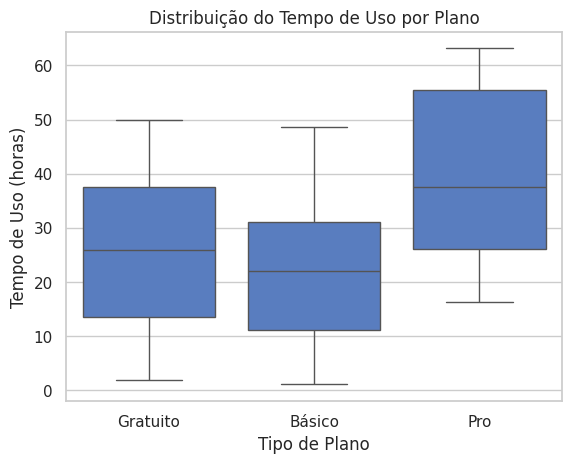

In [7]:
sns.boxplot(data=df_sistema, x='plano', y='tempo_uso_horas')
plt.title('Distribuição do Tempo de Uso por Plano')
plt.xlabel('Tipo de Plano')
plt.ylabel('Tempo de Uso (horas)')
plt.show()

4. Crie um violinplot cruzando o plano com a satisfacao. Esse gráfico ajudará a entender não apenas a mediana, mas a densidade das notas dadas pelos clientes de cada plano.<br>


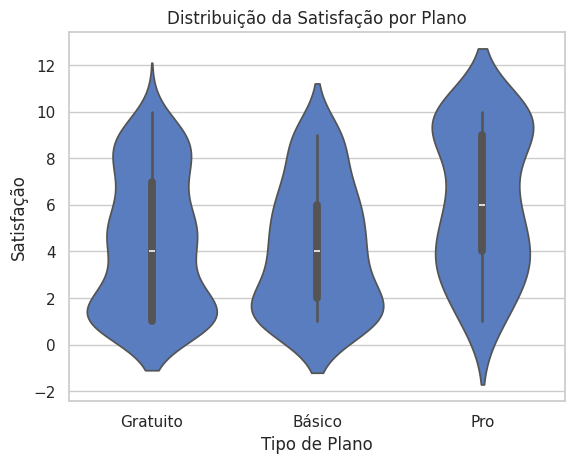

In [8]:
sns.violinplot(data=df_sistema, x='plano', y='satisfacao')
plt.title('Distribuição da Satisfação por Plano')
plt.xlabel('Tipo de Plano')
plt.ylabel('Satisfação')
plt.show()

#Parte 03
##Correlações e Análise Multivariada (Avançado)

5. Utilize um scatterplot para investigar a relação entre tempo_uso_horas (eixo X) e satisfacao (eixo Y). Utilize o parâmetro hue para colorir os pontos de acordo com o plano e size para variar o tamanho dos pontos com base nos bugs_reportados.<br>


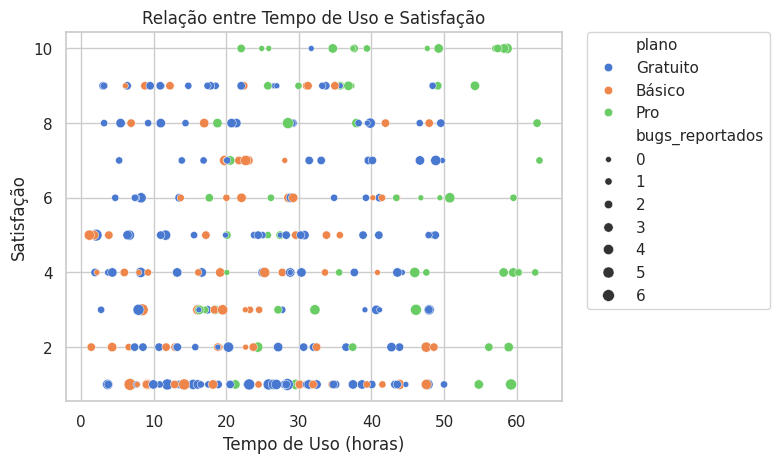

In [14]:
sns.scatterplot(data=df_sistema, x='tempo_uso_horas', y='satisfacao', hue='plano', size='bugs_reportados')
plt.title('Relação entre Tempo de Uso e Satisfação')
plt.xlabel('Tempo de Uso (horas)')
plt.ylabel('Satisfação')
plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left", borderaxespad=0)
plt.show()

6. Calcule a matriz de correlação de Pearson apenas para as variáveis numéricas do DataFrame e visualize-a utilizando um heatmap. Configure a paleta de cores para divergir do centro (ex: 'coolwarm' ou 'vlag') e ative as anotações numéricas (annot=True).<br>


In [19]:
df_sistema.dtypes

,0
idade,int64
plano,object
tempo_uso_horas,float64
bugs_reportados,int64
satisfacao,int64


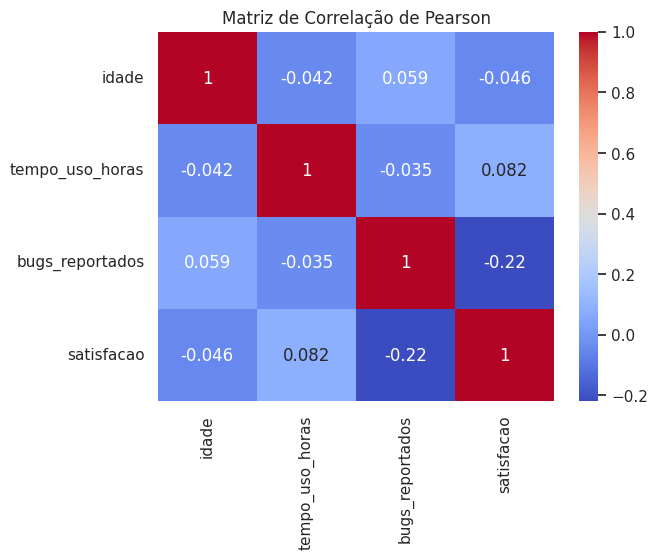

In [20]:
sns.heatmap(df_sistema.drop(columns=['plano']).corr(), cmap='coolwarm', annot=True)
plt.title('Matriz de Correlação de Pearson')
plt.show()

7. (Bônus) Gere um pairplot englobando as variáveis tempo_uso_horas, bugs_reportados e satisfacao, utilizando o plano como hue.<br>


Text(0.5, 1.02, 'Pairplot com Plano como Hue')

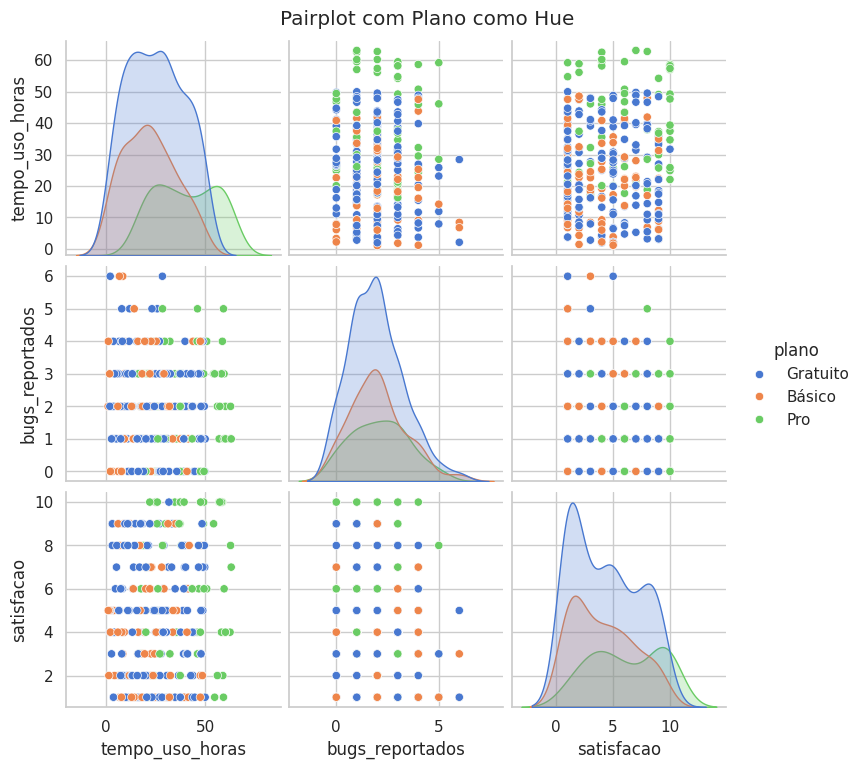

In [23]:
sns.pairplot(df_sistema, hue='plano', vars=['tempo_uso_horas', 'bugs_reportados', 'satisfacao'])
plt.suptitle('Pairplot com Plano como Hue', y=1.02)